In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)

In [2]:
packet_data = pd.read_csv("dataset_tesi_etichettato.csv")
time_format = "%H:%M:%S.%f"

parsed_timestamps = pd.to_datetime(packet_data["Time"], format=time_format)

packet_data["time_sec"] = (

    parsed_timestamps.dt.hour * 3600
    + parsed_timestamps.dt.minute * 60
    + parsed_timestamps.dt.second
    + parsed_timestamps.dt.microsecond / 1000000
)

min_time = packet_data["time_sec"].min()
packet_data["slot_id"] = ((packet_data["time_sec"] - min_time) / 3).astype(int)

window_data = packet_data.groupby("slot_id").agg(

    n_packets=("Len", "count"),
    n_ip=("Src_IP", "nunique"),
    ttl=("TTL", "mean"),
    length=("Len", "mean"),
    iat_mean=("IAT", "mean"),
    iat_std=("IAT", "std"),
    syn=("Flags", lambda x: (x == 2).mean()),
    synack=("Flags", lambda x: (x == 18).mean()),
    pshack=("Flags", lambda x: (x == 24).mean()),
    attack=("Label", lambda x: int(x.mean() >= 0.20)),

).reset_index()

window_data["slot_init_time"] = pd.to_timedelta(window_data["slot_id"] * 3, unit="s")
window_data["slot_init_time"] = window_data["slot_init_time"].astype(str).str.split("days ").str[1]
window_data["pkt_rate"] = window_data["n_packets"] / 3

window_data = window_data.fillna(0)

column_order = [

    "slot_id",
    "slot_init_time",
    "attack",
    "pkt_rate",
    "n_ip",
    "ttl",
    "length",
    "iat_mean",
    "iat_std",
    "syn",
    "synack",
    "pshack",
]

window_data = window_data[column_order]
window_data.to_csv("dataset_processato.csv", index=False)

features = window_data.drop(columns=["attack", "slot_id", "slot_init_time"])
target = window_data["attack"]

X_train, X_test, y_train, y_test = train_test_split(
    
    features, target, test_size=0.30, stratify=target, random_state=42
)

training_set = X_train.copy()
training_set["attack"] = y_train.values
training_set.to_csv("datasetTraining.csv", index=False)

test_set = X_test.copy()
test_set["attack"] = y_test.values
test_set.to_csv("datasetTest.csv", index=False)

print("Preprocessing completato.")

Preprocessing completato.


In [3]:
training_df = pd.read_csv("datasetTraining.csv")
test_df = pd.read_csv("datasetTest.csv")

X_train = training_df.drop(columns=["attack"])
y_train = training_df["attack"]

X_test = test_df.drop(columns=["attack"])
y_test = test_df["attack"]

print(f"Training set: {len(X_train)} campioni, di cui {y_train.sum()} classificati come attacco")
print(f"Test set: {len(X_test)} campioni, di cui {y_test.sum()} classificati come attacco")
print(f"Feature disponibili: {list(X_train.columns)}")

Training set: 615 campioni, di cui 341 classificati come attacco
Test set: 264 campioni, di cui 147 classificati come attacco
Feature disponibili: ['pkt_rate', 'n_ip', 'ttl', 'length', 'iat_mean', 'iat_std', 'syn', 'synack', 'pshack']


In [4]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
mlp_param_grid = {

    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [1e-4, 1e-3],
    "learning_rate_init": [0.001, 0.01],
}

mlp_grid_search = GridSearchCV(

    MLPClassifier(solver="adam", max_iter=1000, early_stopping=True, random_state=42),
    mlp_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)

mlp_grid_search.fit(X_train_scaled, y_train)

print("\nRicerca iperparametri MLP:")
print(f"Migliori iperparametri: {mlp_grid_search.best_params_}")
print(f"F1 medio in validazione incrociata: {mlp_grid_search.best_score_:.4f}")
print(f"Iterazioni del modello ottimale: {mlp_grid_search.best_estimator_.n_iter_} (max_iter=1000)")


Ricerca iperparametri MLP:
Migliori iperparametri: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}
F1 medio in validazione incrociata: 0.9734
Iterazioni del modello ottimale: 12 (max_iter=1000)


In [6]:
decision_tree_param_grid = {

    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

decision_tree_grid_search = GridSearchCV(

    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    decision_tree_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)

decision_tree_grid_search.fit(X_train_scaled, y_train)

print("\nRicerca iperparametri Decision Tree:")
print(f"Migliori iperparametri: {decision_tree_grid_search.best_params_}")
print(f"F1 medio in validazione incrociata: {decision_tree_grid_search.best_score_:.4f}")


Ricerca iperparametri Decision Tree:
Migliori iperparametri: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1}
F1 medio in validazione incrociata: 0.9750


In [7]:
random_forest_param_grid = {

    "n_estimators": [100, 200],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"],
}

random_forest_grid_search = GridSearchCV(

    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42),
    random_forest_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)

random_forest_grid_search.fit(X_train_scaled, y_train)

print("\nRicerca iperparametri Random Forest:")
print(f"Migliori iperparametri: {random_forest_grid_search.best_params_}")
print(f"F1 medio in validazione incrociata: {random_forest_grid_search.best_score_:.4f}")


Ricerca iperparametri Random Forest:
Migliori iperparametri: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
F1 medio in validazione incrociata: 0.9807


In [8]:
model_configs = {

    "MLP": mlp_grid_search.best_estimator_,
    "Decision Tree": decision_tree_grid_search.best_estimator_,
    "Random Forest": random_forest_grid_search.best_estimator_,
}

evaluation_results = {}

for model_name, model in model_configs.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    classification_report_dict = classification_report(y_test, y_pred, output_dict=True)

    evaluation_results[model_name] = {
        
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": classification_report_dict["1"]["precision"],
        "Recall": classification_report_dict["1"]["recall"],
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
    }

results_dataframe = pd.DataFrame(evaluation_results).T

print("\nConfronto delle prestazioni tra i modelli:")
print(results_dataframe.round(5))


Confronto delle prestazioni tra i modelli:
               Accuracy  Precision   Recall  F1-Score  AUC-ROC
MLP             0.96970    0.97279  0.97279   0.97279  0.97692
Decision Tree   0.97348    0.98611  0.96599   0.97595  0.97445
Random Forest   0.98864    0.99315  0.98639   0.98976  0.99855


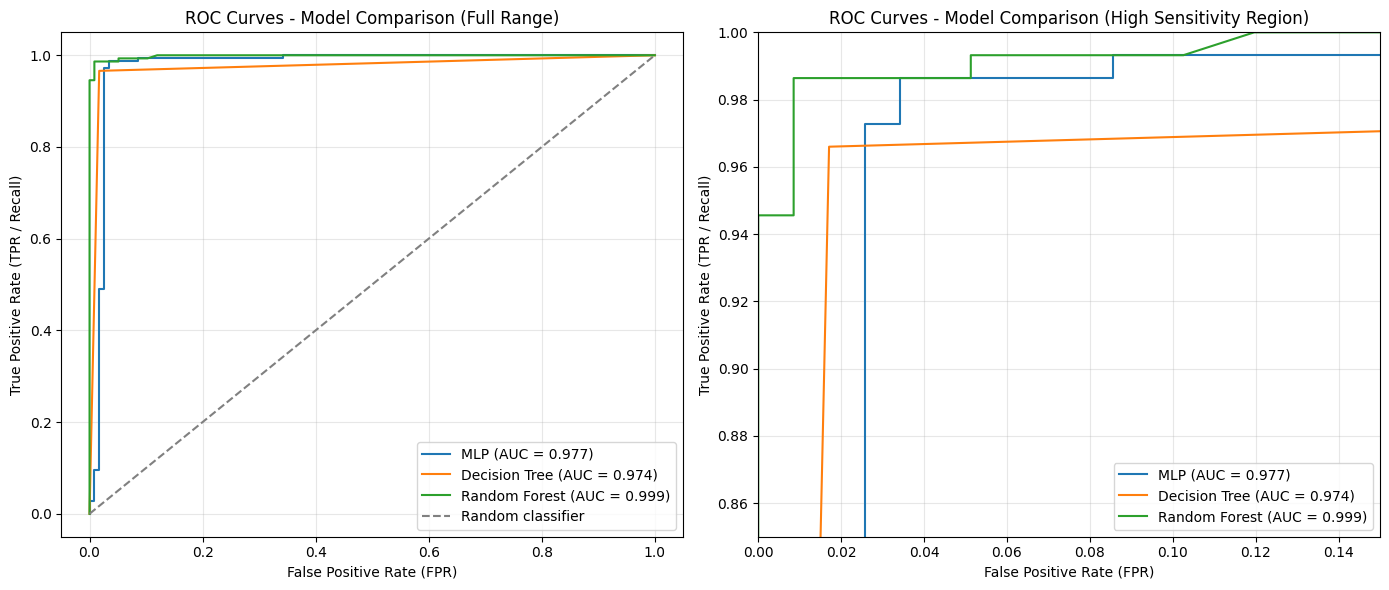

In [9]:
figure, (roc_subplot, roc_subplot_zoom) = plt.subplots(1, 2, figsize=(14, 6))

roc_data = {}

for model_name, model in model_configs.items():

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[model_name] = (fpr, tpr)

for model_name, (fpr, tpr) in roc_data.items():

    roc_subplot.plot(

        fpr, tpr,
        label=f"{model_name} (AUC = {auc(fpr, tpr):.3f})"
    )

roc_subplot.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
roc_subplot.set_xlabel("False Positive Rate (FPR)")
roc_subplot.set_ylabel("True Positive Rate (TPR / Recall)")
roc_subplot.set_title("ROC Curves - Model Comparison (Full Range)")
roc_subplot.legend(loc="lower right")
roc_subplot.grid(alpha=0.3)

for model_name, (fpr, tpr) in roc_data.items():

    roc_subplot_zoom.plot(
        
        fpr, tpr,
        label=f"{model_name} (AUC = {auc(fpr, tpr):.3f})"
    )

roc_subplot_zoom.set_xlabel("False Positive Rate (FPR)")
roc_subplot_zoom.set_ylabel("True Positive Rate (TPR / Recall)")
roc_subplot_zoom.set_title("ROC Curves - Model Comparison (High Sensitivity Region)")
roc_subplot_zoom.set_xlim(0.0, 0.15)
roc_subplot_zoom.set_ylim(0.85, 1.0)
roc_subplot_zoom.legend(loc="lower right")
roc_subplot_zoom.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
for model_name, model in model_configs.items():

    y_pred = model.predict(X_test_scaled)
    print(f"\n{model_name}")
    print(classification_report(y_test, y_pred, target_names=["Normal", "DDoS"]))

    confusion = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:")
    print(f"False Negatives (FN): {confusion[1,0]:4d}    True Positives (TP): {confusion[1,1]:4d}  <- Attack instances")
    print(f"True Negatives  (TN): {confusion[0,0]:4d}    False Positives (FP): {confusion[0,1]:4d}  <- Normal instances")

    print()


MLP
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       117
        DDoS       0.97      0.97      0.97       147

    accuracy                           0.97       264
   macro avg       0.97      0.97      0.97       264
weighted avg       0.97      0.97      0.97       264

Confusion matrix:
False Negatives (FN):    4    True Positives (TP):  143  <- Attack instances
True Negatives  (TN):  113    False Positives (FP):    4  <- Normal instances


Decision Tree
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       117
        DDoS       0.99      0.97      0.98       147

    accuracy                           0.97       264
   macro avg       0.97      0.97      0.97       264
weighted avg       0.97      0.97      0.97       264

Confusion matrix:
False Negatives (FN):    5    True Positives (TP):  142  <- Attack instances
True Negatives  (TN):  115    False Positives (FP):    2 

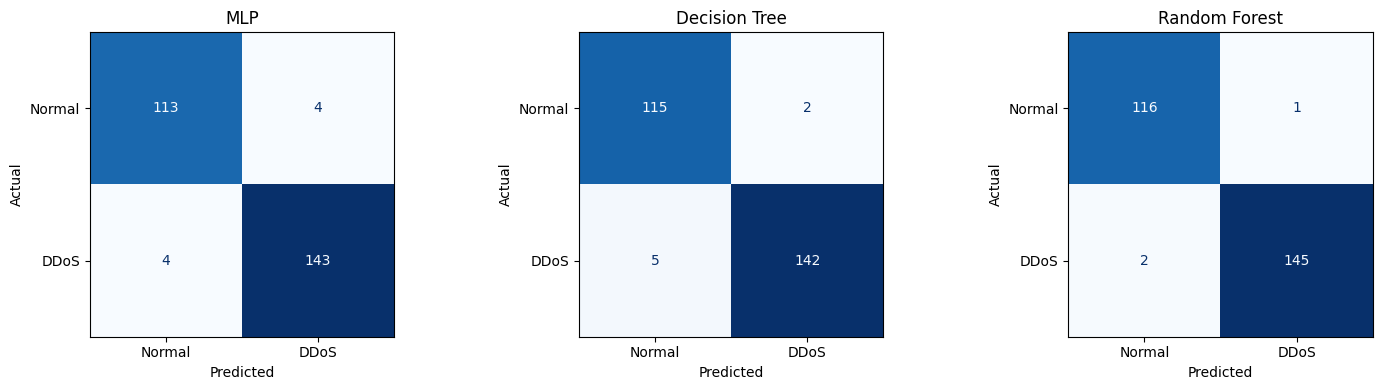

In [11]:
figure, axes = plt.subplots(1, len(model_configs), figsize=(15, 4))

for axis, (model_name, model) in zip(axes, model_configs.items()):

    y_pred = model.predict(X_test_scaled)

    ConfusionMatrixDisplay.from_predictions(

        y_test,
        y_pred,
        display_labels=["Normal", "DDoS"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [12]:
random_forest_model = random_forest_grid_search.best_estimator_
feature_importance_dict = dict(zip(X_train.columns, random_forest_model.feature_importances_))

feature_importance_dataframe = pd.DataFrame(

    list(feature_importance_dict.items()),
    columns=["Feature", "Importance"]
)

feature_importance_dataframe = feature_importance_dataframe.sort_values(

    by="Importance", ascending=False
)

feature_importance_dataframe.set_index("Feature", inplace=True)

print("\nFeature importance computed by Random Forest:\n")
print(feature_importance_dataframe.round(5))


Feature importance computed by Random Forest:

          Importance
Feature             
n_ip         0.42463
ttl          0.22817
iat_std      0.11865
pkt_rate     0.08069
iat_mean     0.05939
pshack       0.02885
syn          0.02552
synack       0.02026
length       0.01385


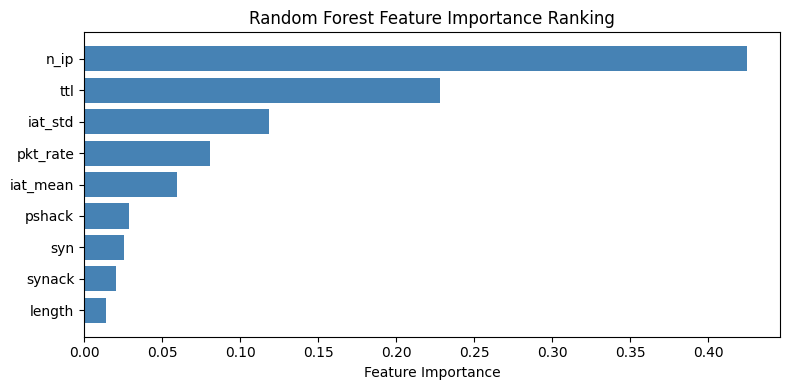

In [13]:
importance_values = feature_importance_dataframe["Importance"].sort_values()

plt.figure(figsize=(8, max(4, 0.4 * len(importance_values))))
plt.barh(importance_values.index, importance_values.values, color="steelblue")

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance Ranking")
plt.tight_layout()
plt.show()